# Extended Wigner's friend scenario (with GHZ friends)

In [11]:
#%pip install pylatexenc

The extended Wigner's friend scenario (EWFS) with GHZ friends. Consider both "random" and "majority vote" approaches. Only consider the semi-Brukner inequality.

## Imports and setup

In [12]:
import os
from datetime import datetime


from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_distribution, plot_histogram

from pytket.extensions.nexus import Nexus

from pytket.extensions.qiskit import qiskit_to_tk, tk_to_qiskit
from pytket.extensions.nexus import Nexus, QuantinuumConfig
from pytket.extensions.nexus.backends import NexusBackend

## Noise models

In [13]:
from utils import depolarizing_noise_model, bitflip_model, DATA_PATH, save_data

In [14]:
# EWFS IMPORTS

from ewfs import ewfs, PEEK, REVERSE_1, REVERSE_2, ANGLES, BETA, decode_results, compute_violations

## Sanity checks (for majority vote approach)

(1, 3)


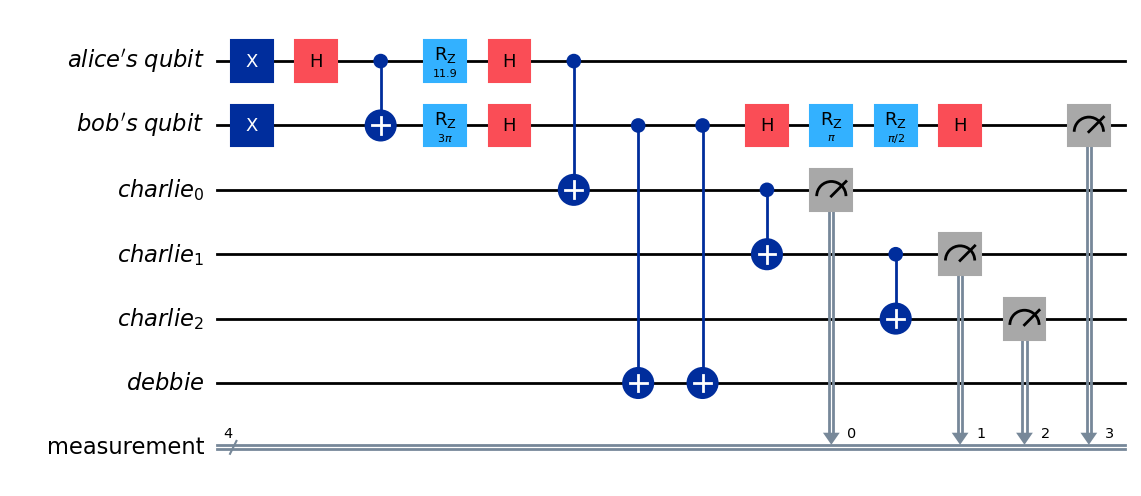

In [5]:
# Print example circuit.
charlie_size = 3
setting = (PEEK, REVERSE_2)
print(setting)
qc = ewfs(setting[0], setting[1], "majority_vote", ANGLES, BETA, charlie_size, 1)
qc_tk = qiskit_to_tk(qc)
qc_qiskit = tk_to_qiskit(qc_tk)
qc_qiskit.draw("mpl", style="default")#.savefig("ewfs_majority_vote_peek_reverse_1.pdf")

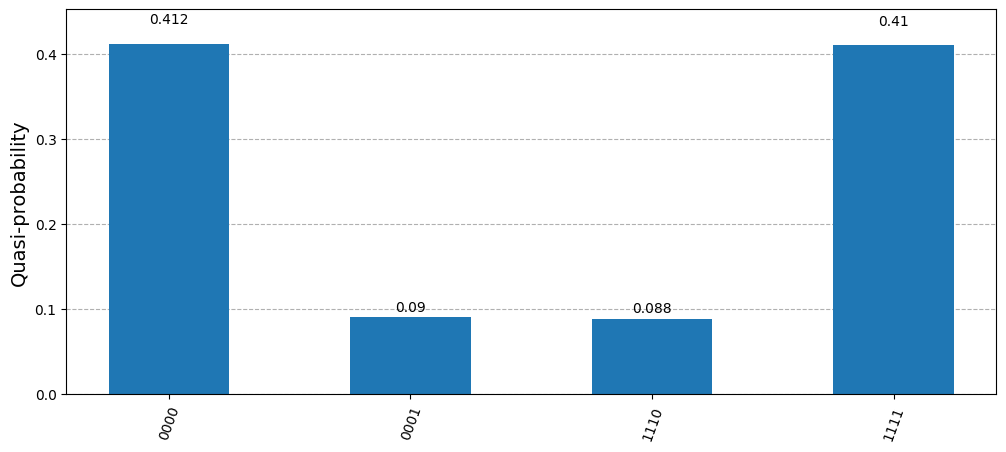

In [6]:
noise_bit_flip = bitflip_model(0.03)
simulator = AerSimulator()#noise_model=noise_bit_flip)
transpiled_qc = transpile(qc, simulator, basis_gates=noise_bit_flip.basis_gates)

job = simulator.run(transpiled_qc, shots=10000)
result = job.result()

counts = result.get_counts()
probabilities = {key[::-1]: value / 10000 for key, value in counts.items()}

plot_histogram(probabilities, figsize=(12, 5))

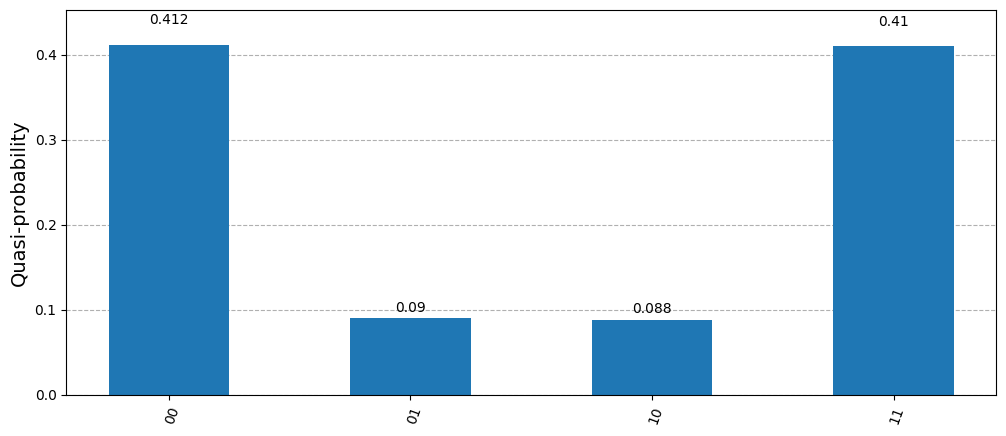

In [7]:
results = {setting: probabilities}
dec_res = decode_results(results, charlie_size)
probs = dec_res[setting]
plot_distribution(probs, figsize=(12, 5))

# Experiment

In [21]:
# Experimental settings:
shots = 1
num_trials = 1
friend_sizes = range(1, 2)
strategy = "majority_vote"
save = False

# Nexus setup:
project_name = "Will-LocalFriendliness"
nexus_project = Nexus().get_project_by_name(project_name)
# config = AerConfig()
# backend_name = "simulator"

# Create timestamped directory to save results.
backend_name = "H1-1"
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
new_dir_name = f"{strategy}_{backend_name}_{timestamp}"
new_dir_path = os.path.join(DATA_PATH, new_dir_name)

if not os.path.exists(new_dir_path):
    os.makedirs(new_dir_path)

# Example of building a NexusBackend from a QuantinuumConfig
configuration = QuantinuumConfig(device_name=backend_name, user_group="DEFAULT")
backend = NexusBackend(configuration, nexus_project)

# backend.cost(circuit, shots)

all_experiment_combos = [[PEEK, REVERSE_1], [PEEK, REVERSE_2], [REVERSE_2, REVERSE_1], [REVERSE_2, REVERSE_2]]
for charlie_size in friend_sizes:
    for trial in range(num_trials):
        results = {}
        for setting in all_experiment_combos:
            # Create timestamped directory to save results.
            timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")

            qc = qiskit_to_tk(ewfs(setting[0], setting[1], "majority_vote", ANGLES, BETA, charlie_size, 1))
            # print(qc)
            # qc.rename_units({'Measurement': 'measurement'})
            nexus_compile_job = nexus_project.submit_compile_job(
                backend_config=configuration,
                circuits=[qc],
                name=f"compile_job_charlie_size_{charlie_size}_{timestamp}",
                optimisation_level=0,
            )
            print("sending for compile", setting)
            nexus_compile_job.wait_for()
            print("got compile")

            # Use zip to pair compiled circuits with their corresponding settings

            execute_job_name = f"execute_job_charlie_size_{charlie_size}_{timestamp}_{(setting[0], setting[1])}"

            compiled_circuit = nexus_compile_job.get_compiled_circuits()[0]
            print("asking for cost")

            cost = backend.cost(compiled_circuit, shots, 'H1-1SC')
            print("Estimated Cost: ", cost)
            
            nexus_execute_job = nexus_project.submit_execute_job(
                backend_config=configuration,
                circuits=[compiled_circuit],
                n_shots=[shots],
                name=execute_job_name,
            )

            nexus_execute_job.wait_for()
            result = nexus_execute_job.get_results()

            probabilities = {''.join(map(str, k)): v / shots for k, v in dict(result[0].get_counts()).items()}
            results[tuple(setting)] = probabilities
    
        violations = compute_violations(
            results=results, 
            charlie_size=charlie_size, 
            debbie_size=1, 
            strategy=strategy,
            verbose=True,
        )
        print(f"Violations: {violations}\n")
        # Save data after each trial of each charlie_size.
        if save:
            save_data(results=results,
                      friend_size=charlie_size,
                      trial=trial,
                      shots=shots,
                      data_path=new_dir_path,
                      backend_name=backend_name)


Started using project with name: Will-LocalFriendliness
sending for compile [1, 2]
got compile
asking for cost


KeyboardInterrupt: 